

# Data 실습


(4, 1)
(4,)


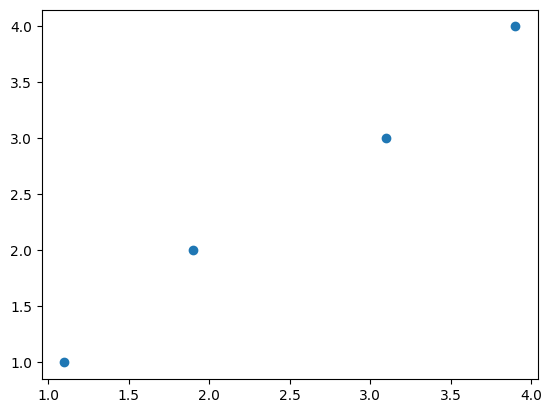

In [9]:
# 실습 1 # y=wx+b 그래프 도출
# 결측값 조정 -> 스케일 조정 순으로 진행
# 스케일 조정? 속성간의 차이를 조정 => 표준화!!

import numpy as np
import matplotlib.pyplot as plt        # 그래프 만들어주는 기능

x_data = np.array([[1.1],[1.9],[3.1],[3.9]])
y_data = np.array([1,2,3,4])

print(x_data.shape)
print(y_data.shape)
plt.plot(x_data,y_data, "o")
plt.show()

In [10]:
# 실습 1-1 선형회귀 모델 만들기

from sklearn.linear_model import LinearRegression
lr = LinearRegression()                           # 선형데이터로 지정
lr.fit(x_data, y_data)                            # fit : x_data, y_data를 학습해서 w와 b 를 도출하고 저장함

LinearRegression()

In [11]:
# 실습 1-2 lr 모델의 기울기와 절편

lr.coef_, lr.intercept_ # 기울기(w) 와 절편(b)

(array([1.03448276]), np.float64(-0.0862068965517242))

In [17]:
# 실습 1-3 학습된 데이터를 통해 값을 넣고 예측값 도출

lr.predict([[5.0], [0.9], [0.1]])

array([5.0862069 , 0.84482759, 0.01724138])

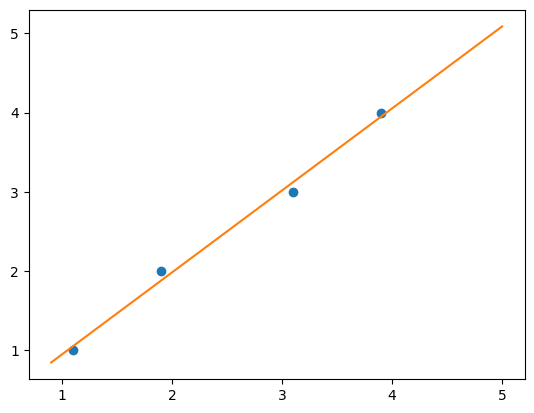

In [19]:
# 실습 1-4 # 선형회귀식 산출

import matplotlib.pyplot as plt

plt.plot(x_data,y_data, "o")

plt.plot([0.9, 5.0], [0.84482759, 5.0862069])    # x축, y축 별로 지정해서 그려짐
plt.show()                                       # 예측모델을 통한 선형회귀식 도출

In [21]:
# 실습 1-5 오차 평가 MSE 로 검증

np.mean((y_data - lr.predict(x_data))**2)

np.float64(0.008620689655172455)

In [22]:
# 실습 1-6 r2_score 를 통해 정답과 예측값의 신뢰도 검증

from sklearn.metrics import r2_score
r2_score(y_data, lr.predict(x_data))   # 신뢰도 99.3%

0.993103448275862

[ 0.27626589 -1.85462808  0.62390111  1.14531129  1.03719047  1.88663893
 -0.11169829 -0.36210134  0.14867505 -0.43778315]
[0 1 2 3 4 5 6 7 8 9]
[ 0.27626589 -0.85462808  2.62390111  4.14531129  5.03719047  6.88663893
  5.88830171  6.63789866  8.14867505  8.56221685]


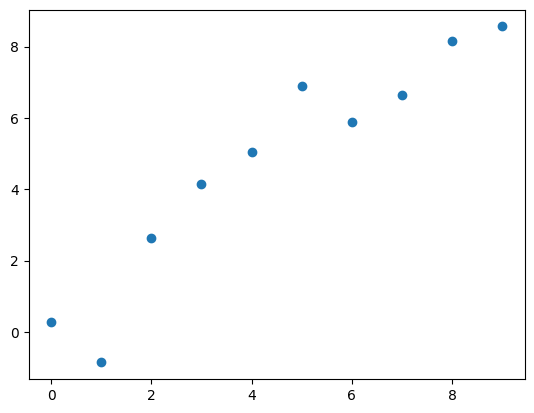

In [49]:
# 실습 2 선형회귀 과정(fit)의 for문 작업을 통한 이해

# 각 요소 설명
np.random.seed(17)
print(f"{np.random.randn(10)}")                  # 정규분포(평균 0, 표준편차 1)를 따르는  10개 생성
print(np.arange(10))                             # 0~9까지 생성
print(y_data)

np.random.seed(17)
x_data = np.arange(10)
y_data = np.arange(10) + np.random.randn(10)
plt.plot(x_data, y_data, "o")
plt.show()

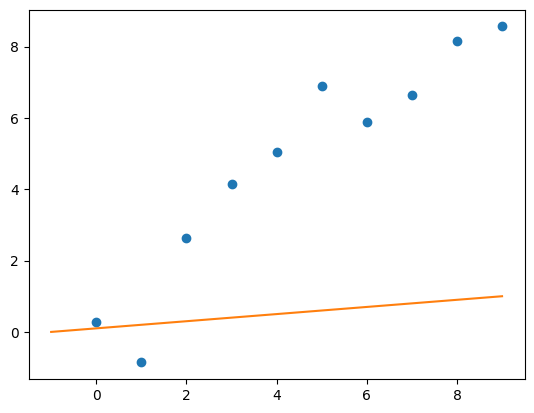

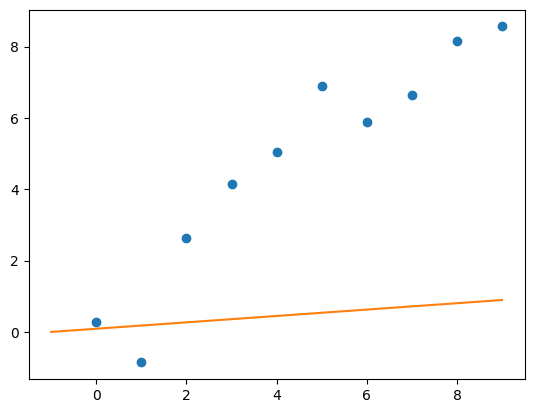

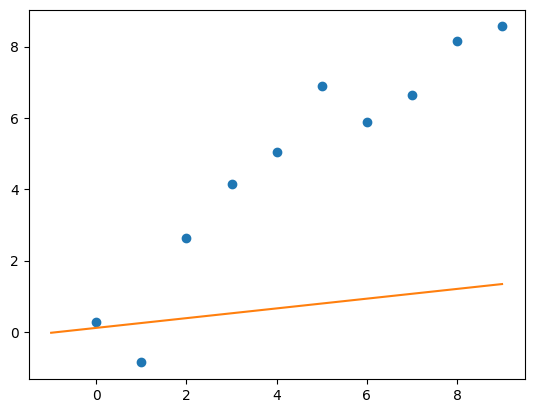

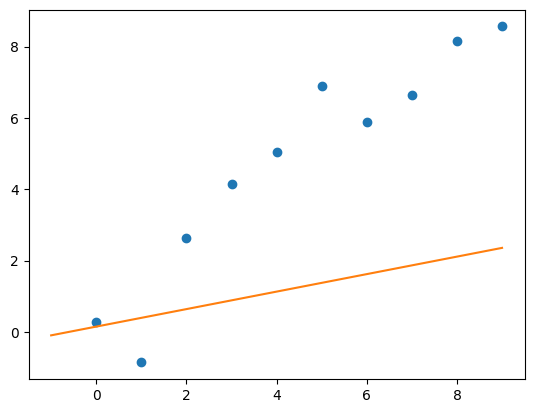

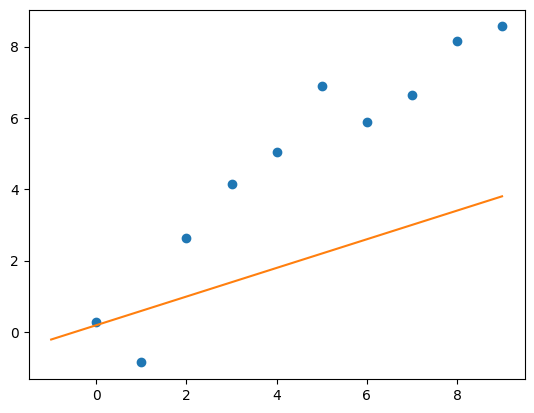

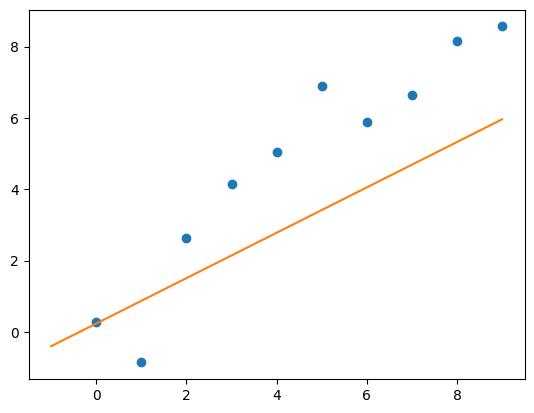

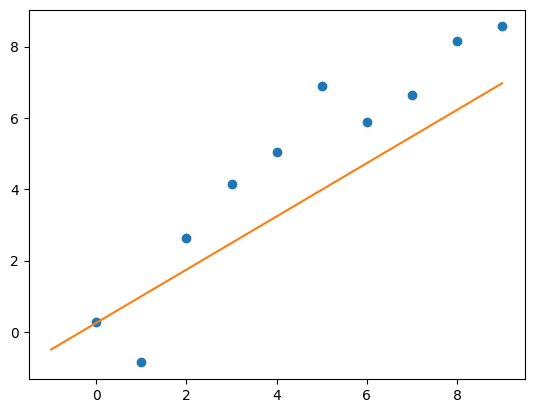

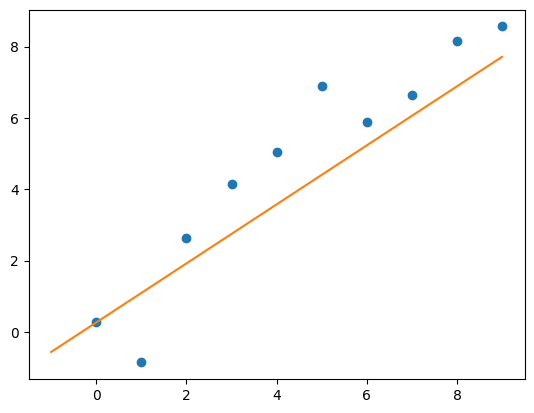

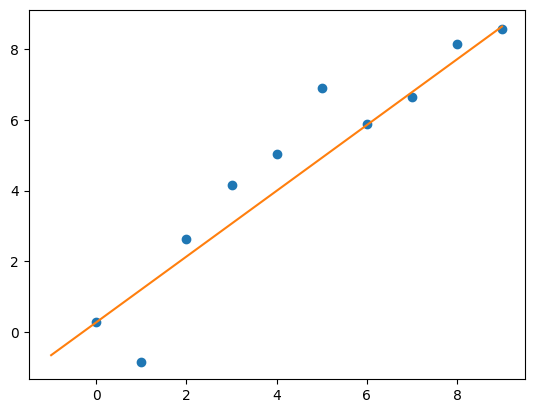

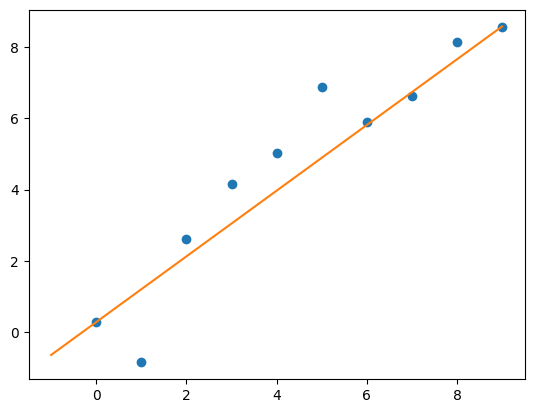

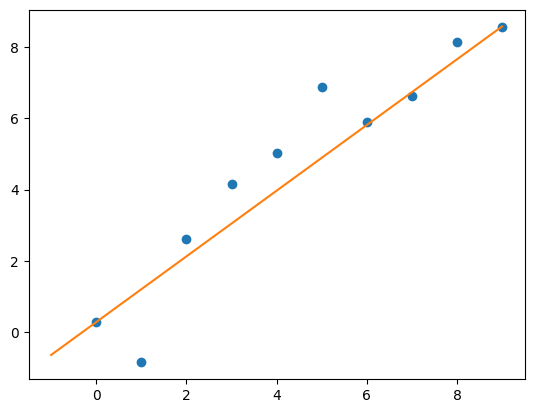

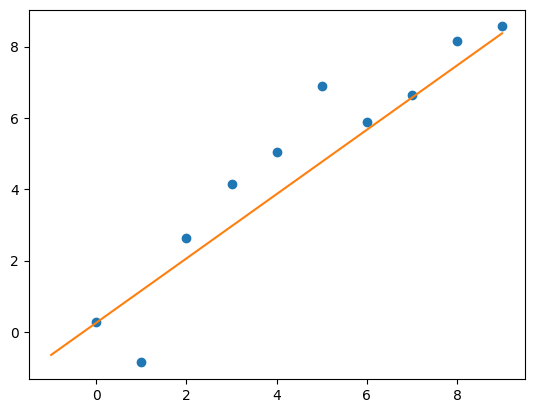

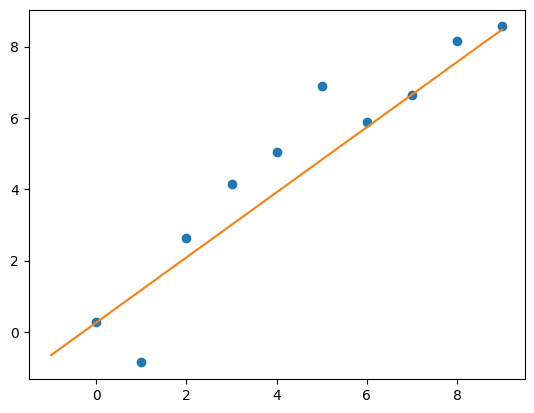

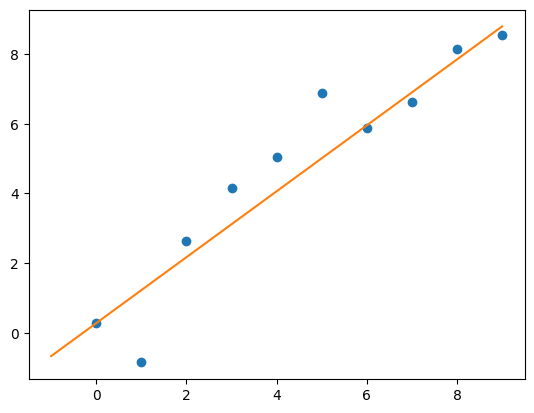

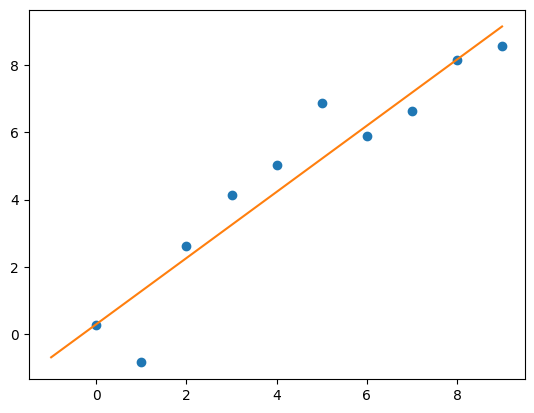

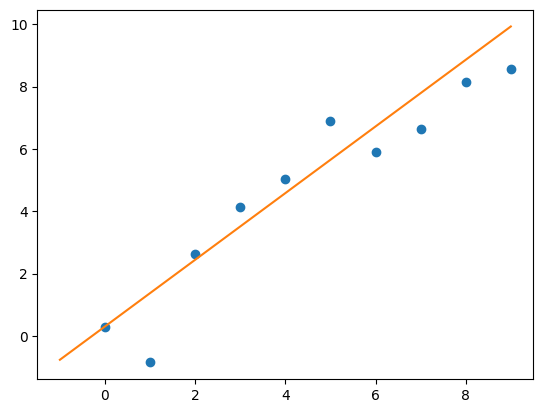

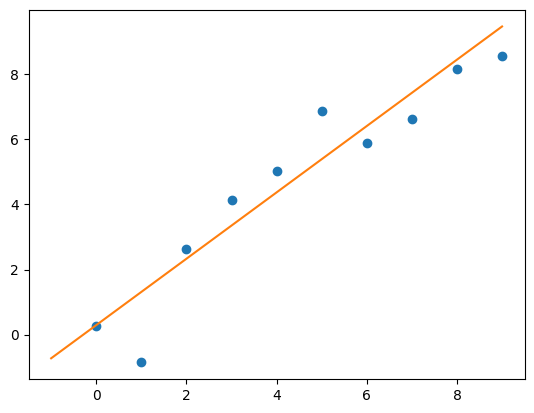

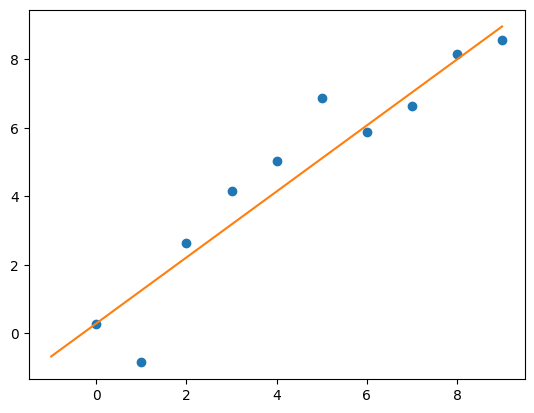

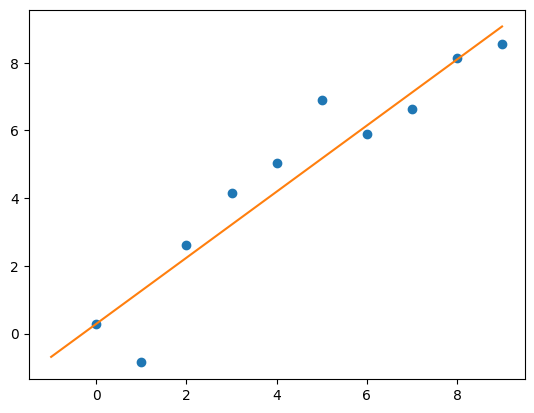

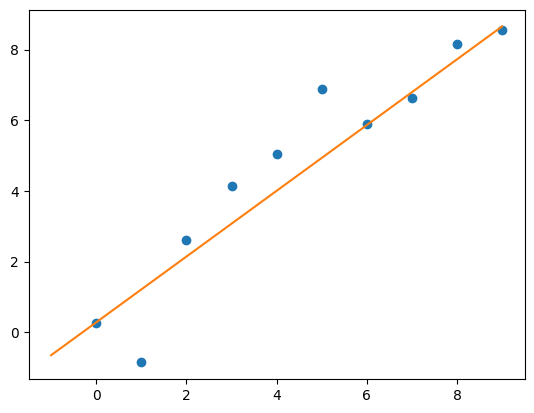

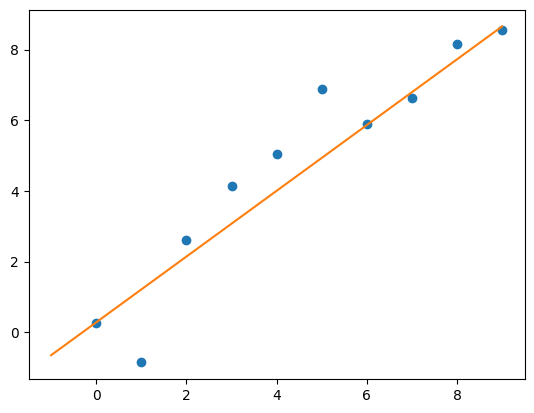

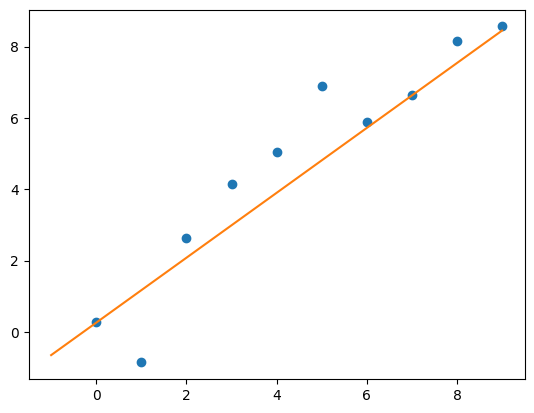

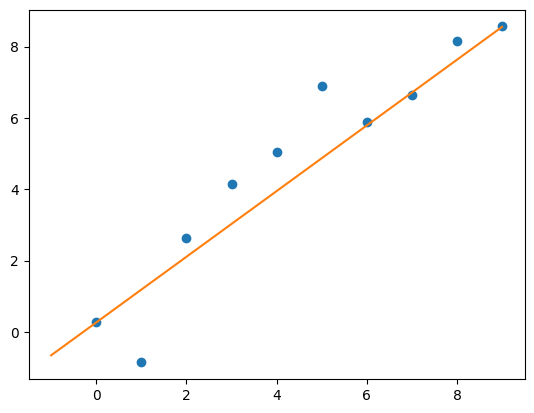

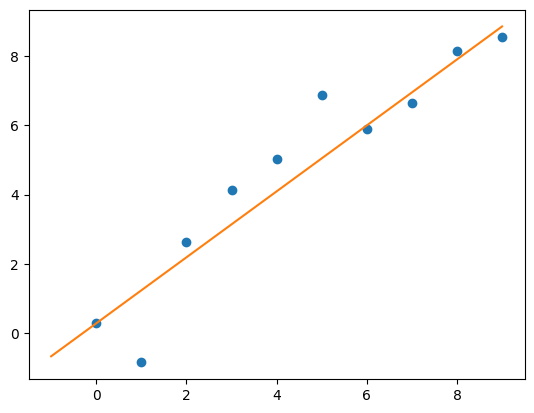

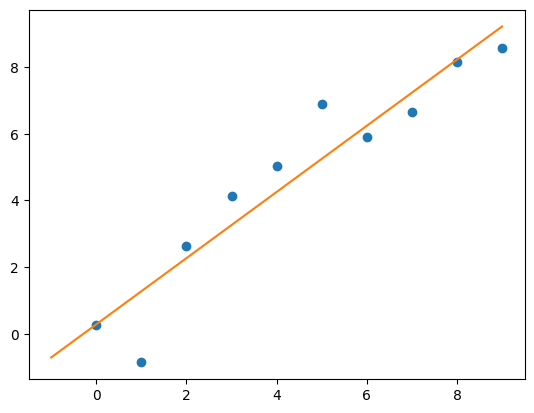

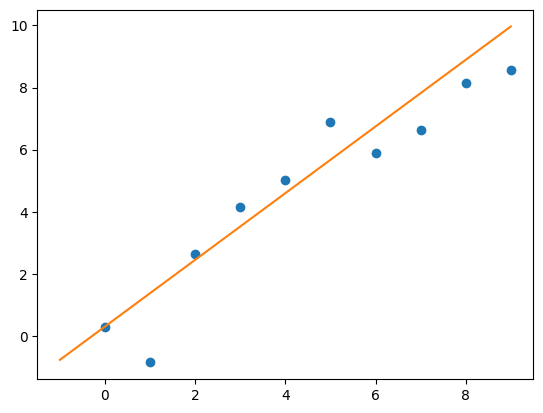

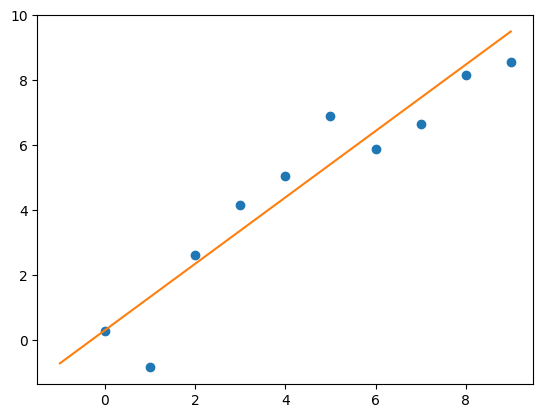

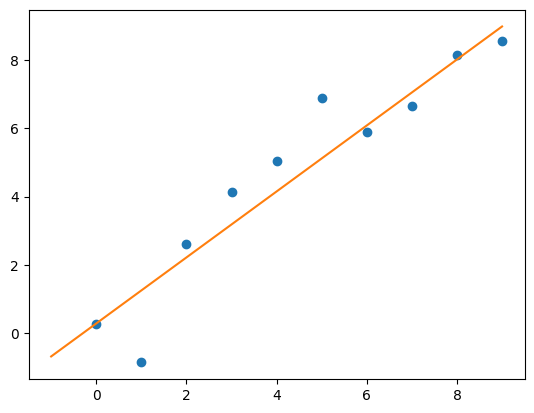

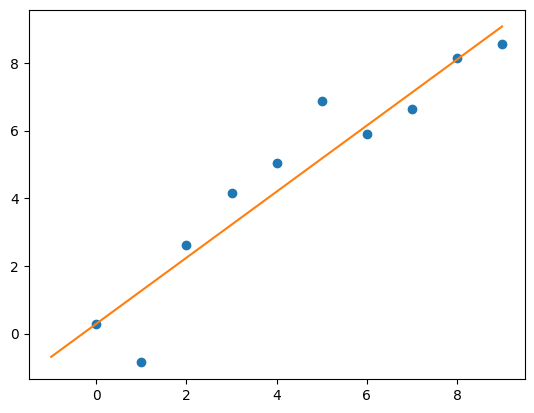

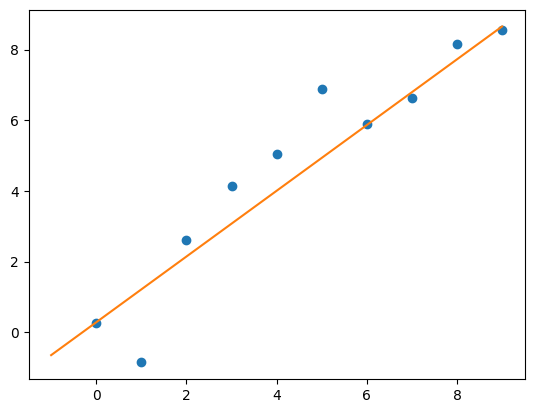

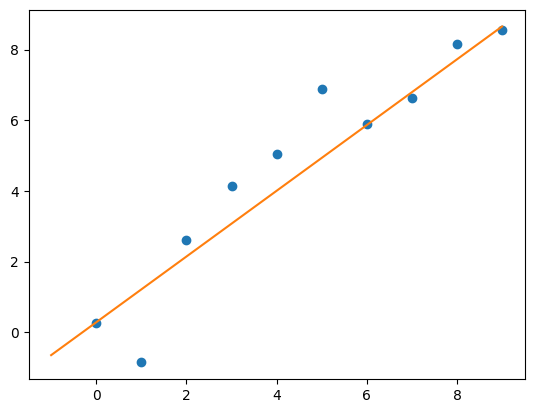

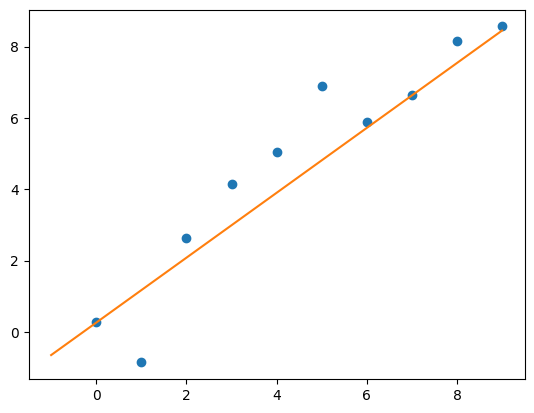

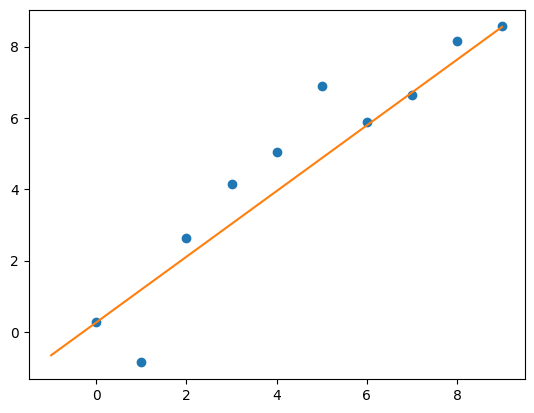

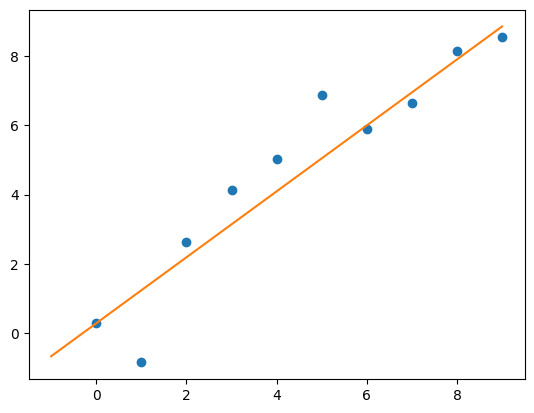

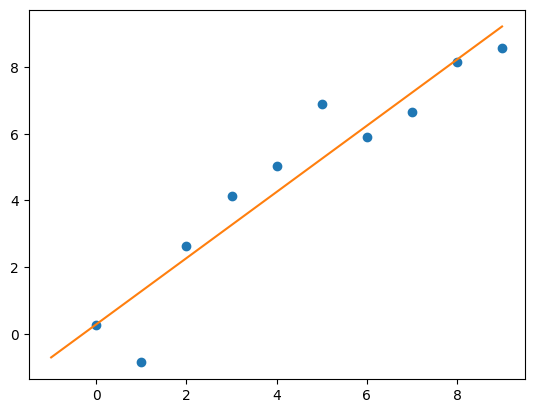

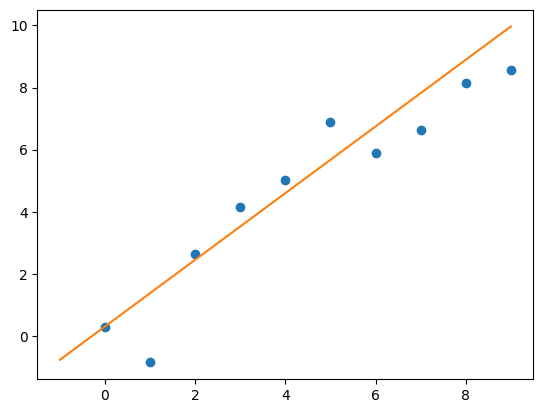

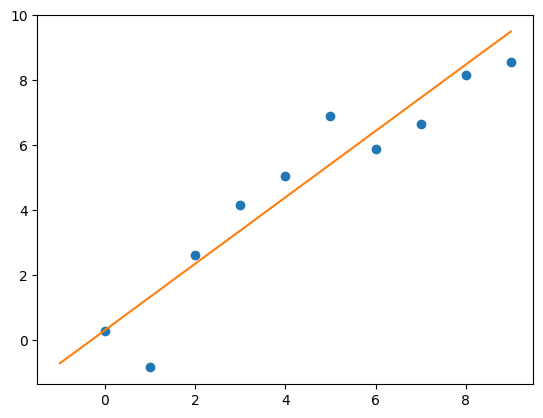

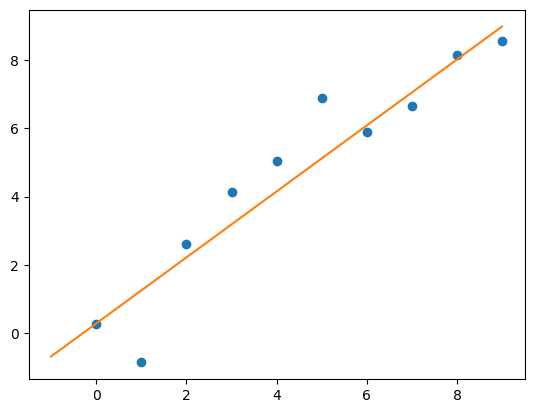

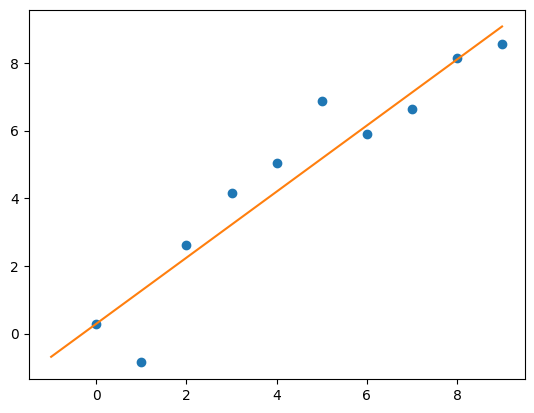

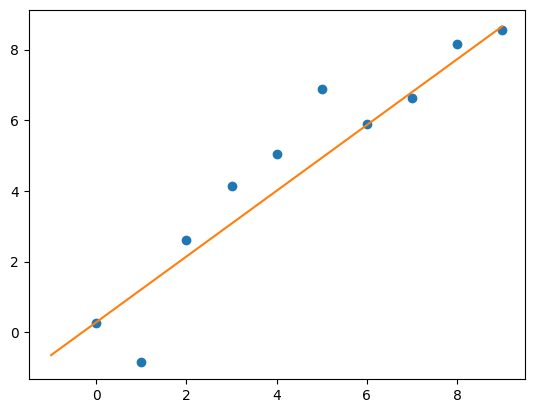

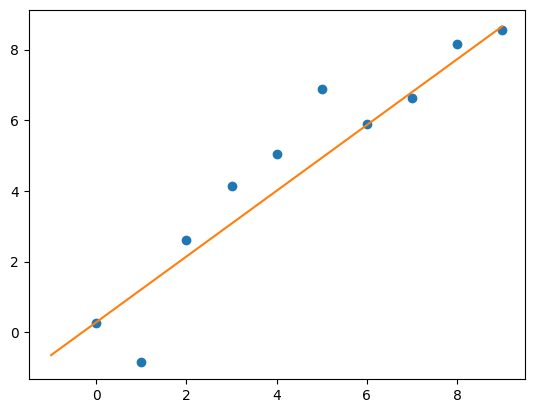

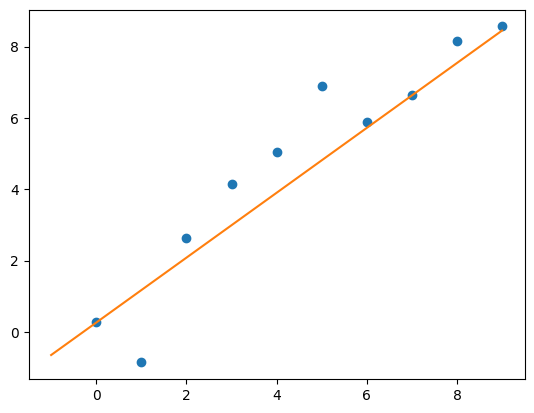

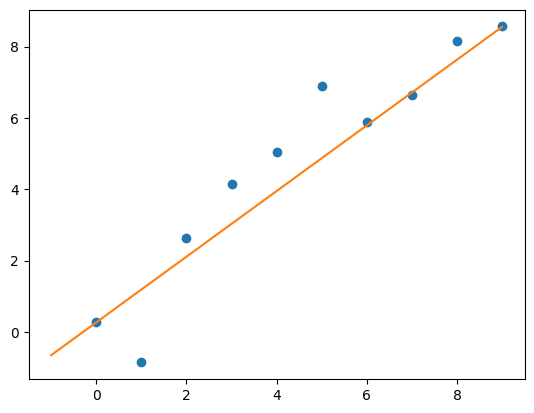

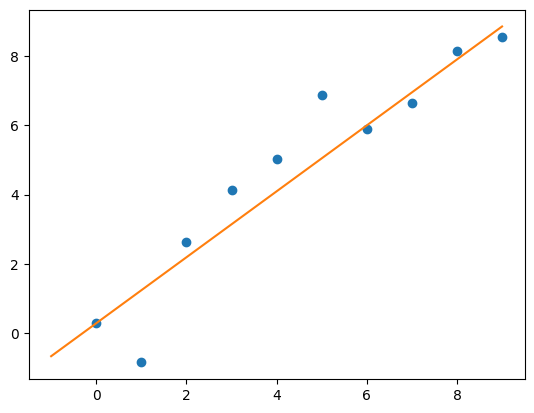

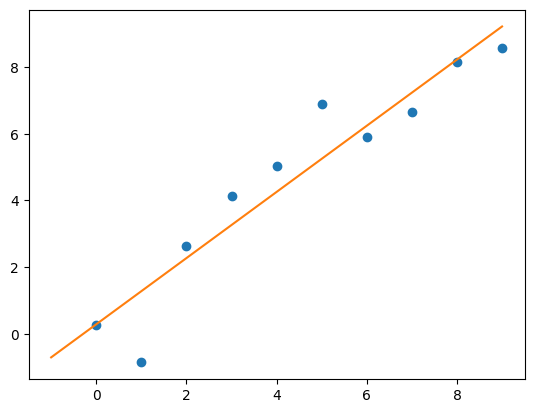

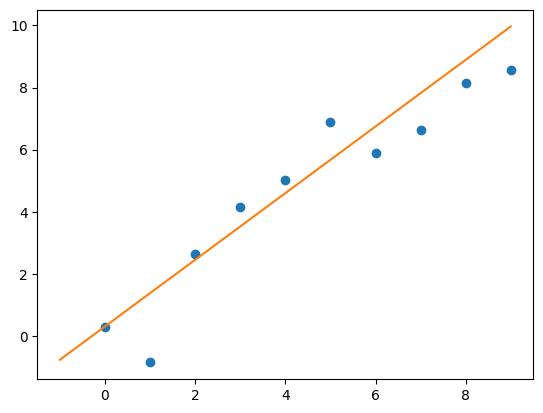

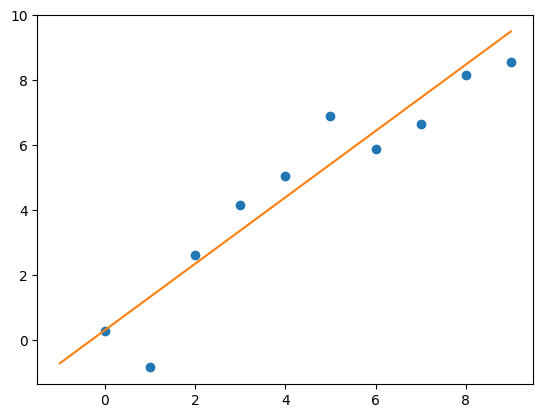

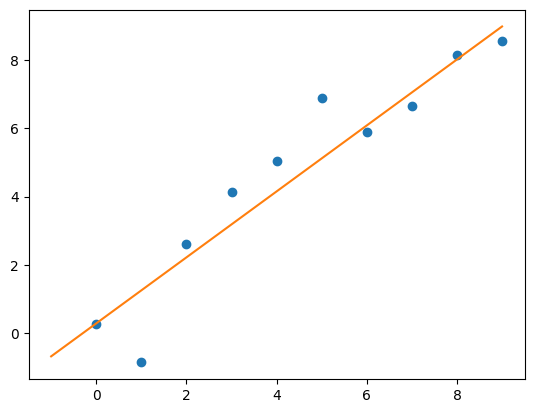

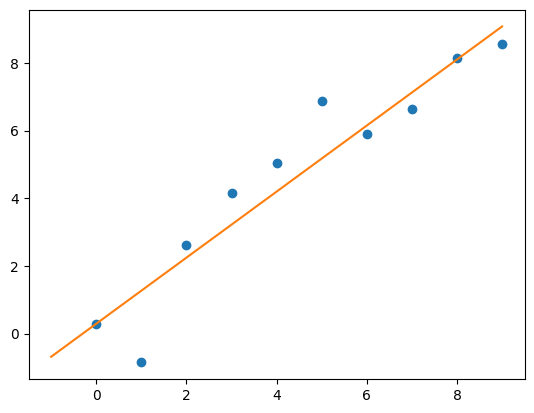

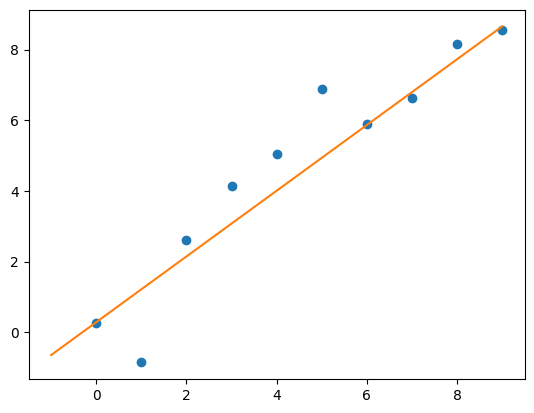

In [61]:
# 실습 2-1 for문을 통해 모델 학습시키는 과정을 확인하기
# 오차를 줄이는 방향으로 예측값에 가까워지는 for 문임(SGD 방식 ---- batch 방식)

w, b = 0.1, 0.1
learning_rate = 0.01
for _ in range(5):                     # 5 epoch : 데이터 학습과 조정을 5번 시킴
  for x, y in zip(x_data, y_data):
    y_hat = w * x + b
    err = y - y_hat
    w = w + learning_rate * err * x
    b = b + learning_rate * err * 1

    #print(x, y, y_hat, err, w,b)

    plt.plot(x_data,y_data, "o")
    plt.plot([-1, 9], [w*-1+b, w*9+b])   # 그래프를 그려보면서 이해
    plt.show()

In [63]:
# 실습 3 SGDRegerssor

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

sgd = SGDRegressor()
sgd.fit(x_data.reshape(-1,1), y_data)       # 1번축을 1개로 정하고 나머지는 알아서해라(-1) : fit 은 2차원 이어야 진행되기 때문
y_hats = sgd.predict(x_data.reshape(-1,1))  # 경사하강법을 적용해서 학습을 진행할 수 있음

print(sgd.coef_, sgd.intercept_)            # (기울기, 절편값)
print(mean_squared_error(y_data, y_hats))   # 잔차 평균을 구하는 것
print(r2_score(y_data, y_hats))             # 신뢰도 구하기

[0.99862618] [0.17382578]
0.9701811716757126
0.8944324830360956


In [85]:
# 실습 3-1 SGDRegerssor 를 당뇨병 데이터 셋으로 적용

from sklearn.linear_model import SGDRegressor
from sklearn.datasets import load_diabetes                    # 당뇨 환자 데이터 셋
diabet = load_diabetes()                                      # 셋 불러오기
diabet_sgd = SGDRegressor(max_iter=10000)                     # SGD 적용
diabet_sgd.fit(diabet.data, diabet.target)                    # 데이터 학습시키기(2차원인 경우 reshape 적용할 필요 없음)

SGDRegressor(max_iter=10000)

In [86]:
# 실습 3-2 기울기와 절편 구하기                              # train, test 데이터 구분안한 상태


target_hats = diabet_sgd.predict(diabet.data)

print(diabet_sgd.coef_, diabet_sgd.intercept_)
print(mean_squared_error(diabet.target, target_hats))       # 잔차 평균(정답지와 예측한 수치들)
print(r2_score(diabet.target, target_hats))                 # 신뢰도 점수(정답지와 예측한 수치들)

[  18.09113331 -159.51871725  444.07585275  281.43694898  -25.37065405
  -83.52656841 -200.42089604  133.02427464  369.86241807  130.40411401] [152.1660098]
2941.414846449648
0.5039676321572113


In [98]:
# 실습 4-1 # train 데이터와 test 데이터 구분하여 적용

from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

diabet = load_diabetes()
x_train, x_test, y_train, y_test = train_test_split(diabet.data, diabet.target)   # 샘플데이터의 선정 및 비율 미정으로 인해 데이터들이 변하면서 잔차평균과 신뢰도 수치가 달라짐

# 1일차에 했던 거 참조                                                       # test 크기 조정   # 모집단 라벨의 비율을 계산해서 샘플 데이터 비율 적용  # 시드값 고정
# x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3,   stratify = iris.target                         ,random_state=7 )


diabet_sgd = SGDRegressor(max_iter=10000)
diabet_sgd.fit(x_train, y_train)                      # 훈련 데이터로 학습시키기
print(diabet_sgd.coef_, diabet_sgd.intercept_)          # 학습시킨 함수의 기울기와 절편

pred = diabet_sgd.predict(x_test)                     # test값들을 예측시킨 것 => pred 라고 부름
print(mean_squared_error(y_test, pred))               # y_test(test의 정답지)와 예측한 값의 잔차 평균
print(r2_score(y_test, pred))                         # 신뢰도

[  24.80231076 -166.19928296  430.72248805  288.85495674  -57.32886236
  -98.69831594 -198.03790184  140.76276974  344.14235499  144.8784268 ] [152.91725641]
3049.2998072895607
0.5250056137001924


# 선형회귀 추가 내용

PolynomialFeatuers : n차항에 대해서 예측할 수 있게 함

* 규제항
  - 릿지(ridge) : 제곱의 규제항이 추가된 선형 회귀
  - 라쏘(lasso) : 절댓값의 규제항이 추가된 선형 회귀
  - 엘라스틱넷(elastticnet) : 릿지와 라쏘 혼합

# 로지스틱 회귀 실습

In [109]:
# 실습 5 로지스틱 회귀 실습 데이터 불러오기

from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()                               # breast_cancer 데이터 셋 사용

print(bc.DESCR)                                         # 표준화 안된 자료

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

사례 수: 569건

속성의 수: 30개의 숫자, 예측 속성 및 클래스

속성 정보:
- 반지름(중심에서 둘레의 점까지의 거리 mean)
- 텍스처(그레이 스케일 값의 표준 편차)
- 둘레
- 면적
- 부드러움(반지름 길이의 국부적 변화)
- 콤팩트성 (perimeter^2 / 면적 - 1.0)
- 오목성(윤곽의 오목한 부분의 severity)
- 오목한 점(윤곽의 오목한 부분 수)
- 대칭성
- 프랙탈 차원 ("coastline 근사" - 1)

CLASS:
- WDBC-악성
- WDBC-양성



In [110]:
bc.data[0], bc.target[0]

(array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01]),
 np.int64(0))

In [112]:
# 실습 5-1 스케일 조정하기(= 표준화)
from sklearn.preprocessing import StandardScaler # 표준화 시켜주는 기능

zs = StandardScaler()                           # 평균과 분산 학습시키는 기능 적용(zs라고 부름)
zs.fit(bc.data)                                 # 각 속성별로 평균, 분산을 계산하는 학습을 시킴
#print(zs.mean_, zs.var_ )

bc_zs = zs.transform(bc.data)                   # 스케일 조정(표준화)
print(bc.data[1])  # 표준화 전
print("==========")
print(bc_zs[1])    # 표준화 후

[2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
 7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
 5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
 2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
 2.750e-01 8.902e-02]
[ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
 -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
  1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
  2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
 -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
  1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
 -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
 -2.43889668e-01  2.81189987e-01]


In [117]:
# 실습 5-2 스케일 조정(StandardScaler)을 좀더 직관적으로 연습

x_data = np.array([[20,50000000],[30, 70000000],[50,90000000]])
zs = StandardScaler()
zs.fit(x_data)
print(zs.mean_, zs.var_)               # 각 속성의 평균과 분산

x_data_zs = zs.fit_transform(x_data)   # fit_transform : 표준화 적용 -> (20-33.3) / 155.5 = 약 -1.069

print(x_data[0])
print(x_data_zs[0])

[3.33333333e+01 7.00000000e+07] [1.55555556e+02 2.66666667e+14]
[      20 50000000]
[-1.06904497 -1.22474487]


In [122]:
# 실습 5-3

from sklearn.linear_model import LogisticRegression

bc = load_breast_cancer()           # breast_cancer 데이터 셋 사용
zs = StandardScaler()               # 표준화 진행 기능

# 표준화 적용
                                                                                    # fit 과  transform 차이
zs.fit(bc.data)                     # bc 데이터를 표준화에 학습시킴 //                  학습 기준을 정해주는 것
print(zs.mean_, zs.var_)            # 표준화 한 것의 평균과 분산
bc_zs = zs.transform(bc.data)       # bc_zs는 bc데이터를 표준화 한 것으로 대체한 것임 // 변환해서 저장해주는 것

# train과 test 데이터 구분

x_train, x_test, y_train, y_test = train_test_split(bc_zs, bc.target)  # x는 bc_zs 를 반영, y에는 bc 정답을 반영

# 로지스틱 적용

lr = LogisticRegression()           # 로지스틱을 적용할 것
lr.fit(x_train, y_train)            # train 데이터를 로지스틱으로 학습
pred = lr.predict(x_test)           # x의 test 데이터로 예측 해보기(pred)
print(pred)


print((y_test==pred).mean())        # mean : 정답지와 예측값이 같은 정답을 맞춘 개수 / 전체 개수 => (정확도)

[1.41272917e+01 1.92896485e+01 9.19690334e+01 6.54889104e+02
 9.63602812e-02 1.04340984e-01 8.87993158e-02 4.89191459e-02
 1.81161863e-01 6.27976098e-02 4.05172056e-01 1.21685343e+00
 2.86605923e+00 4.03370791e+01 7.04097891e-03 2.54781388e-02
 3.18937163e-02 1.17961371e-02 2.05422988e-02 3.79490387e-03
 1.62691898e+01 2.56772232e+01 1.07261213e+02 8.80583128e+02
 1.32368594e-01 2.54265044e-01 2.72188483e-01 1.14606223e-01
 2.90075571e-01 8.39458172e-02] [1.23970943e+01 1.84663974e+01 5.89402799e+02 1.23625903e+05
 1.97452073e-04 2.78428549e-03 6.34407875e-03 1.50301462e-03
 7.50222008e-04 4.97611152e-05 7.67671984e-02 3.03781123e-01
 4.08071149e+00 2.06579462e+03 8.99927022e-06 3.20139261e-04
 9.09596835e-04 3.80055080e-05 6.82128053e-05 6.98938631e-06
 2.33191693e+01 3.77100918e+01 1.12714643e+03 3.23597671e+05
 5.20403629e-04 2.47112650e-02 4.34475982e-02 4.31314711e-03
 3.82085668e-03 3.25636075e-04]
[0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0
 0 0 1 